In [1]:
import sys
print(sys.executable)

import numpy, scipy, matplotlib
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("matplotlib", matplotlib.__version__)


C:\Users\razan\anaconda3\envs\anaconda-2025.12-py3.13\python.exe
numpy 2.3.5
scipy 1.16.3
matplotlib 3.10.6


In [2]:
#libraries
import numpy as np
import matplotlib.pyplot as plt


# Step 1: Generate a synthetic extracellular recording that mimics the real data.
**Why synthetic data?** To benchmark denoisers fairly, I need the *true clean signal* to
compare against. Real recordings never come with a clean reference. So I build the clean
signal myself, add noise, denoise it, then compare back to the known clean version:

`clean (I build it) → + noise → noisy → [denoise] → compare back to clean`

## Stage 1: Build a clean recording:
- A real extracellular action potential is **asymmetric**: a sharp, deep negative trough,
  then a smaller and slower positive rebound.
- Ricker is **symmetric**, so it can't match this. DoG builds the trough and rebound as two
  separate Gaussians, so I can control them independently (`peak_ratio` sets how big the
  rebound is relative to the trough).
- Also, `scipy.signal.ricker` was removed in recent SciPy versions, so it may not
  import. DoG is just `np.exp` — no dependency.

Template is normalised so the trough = **−1.0**, so the channel map can scale it cleanly

In [3]:
def make_spike_template (fs=20000, duration_ms=2.0,
                         trough_pos=0.4, trough_width=0.12,
                         peak_pos=0.6, peak_width=0.25, peak_ratio=0.4):
    """
    One extracellular AP template, normalised so teh trough (min) = -1.0.
    Built as a difference of gaussians : sharp negative trough + slower positive rebound. 
    possitions are fractions of the window(0..1).
    """
    n = int(fs * duration_ms / 1000)   # samples in the window
    t = np.linspace(0, 1, n)    # normalise time 0..1

    trough = -np.exp(-((t - trough_pos)**2) / (2 * trough_width**2))
    peak = peak_ratio * np.exp(-((t - peak_pos)**2) / (2 * peak_width**2))

    wave = trough + peak
    wave = wave / np.abs(wave.min())   # normalise so min = -1.0
    return t, wave

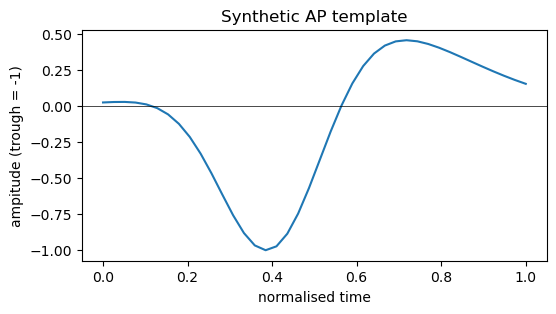

In [4]:
t, wave = make_spike_template()
plt.figure(figsize=(6,3))
plt.plot(t, wave)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("normalised time"); plt.ylabel("ampitude (trough = -1)")
plt.title("Synthetic AP template"); plt.show()

## Stage 2:  channel map (how strong the spike is on each channel):
`amp` = 32 numbers, one per electrode contact. Channel 19 = 1.0 (strongest), fading through
strong neighbours (9, 14, 25, 30) and weak ones (3, 10, 12, 16, 17, 32), and 0 on the rest.

**Physical meaning:** one fibre fires; contacts physically closer to it record a stronger
signal, farther ones weaker, distant ones nothing. So `amp` is the fibre's **spatial
footprint across the electrode**.

**Why this matters (the spine of the project):** each fibre has its own unique pattern across
the 32 channels — its spatial "fingerprint." Sorting tells fibres apart by comparing these
cross-channel patterns, not just spike shape. (My earlier result: F1 ~0.05 on 1 channel →
~0.51 with 3–5 channels.)

> **Viva one-liner:** Per-channel denoising treats channels independently, so it doesn't
> preserve the cross-channel amplitude ratios — and those ratios are exactly what sorting
> relies on. That's why I argue for **joint (multi-channel) denoising**, which cleans all
> channels together and can preserve the pattern.

In [15]:
# How strong the spike looks in each channel
n_channels = 32
amp = np.zeros(n_channels)  # 32 zeros - every channel starts silent 

# the good unit similart to the actual data
amp[18] = 1.0    # channel 19 (19 - 1 = index 18)

# strong neighbours (channels 9, 14, 25, 30)
amp[8] = 0.6   # channel 9
amp[13] = 0.45  # channel 14
amp[24] = 0.7  # channel 25
amp[29] = 0.5   # channel 30

# weak (channels 3, 10, 12, 16, 17, 32
amp[2] = 0.15   # channel 3
amp[9] = 0.1    # channel 10
amp[11] = 0.25  # channel 12
amp[15] = 0.16 # channel 16
amp[16] = 0.22  # channel 17
amp[31] = 0.24  # channel 32

for ch in [19, 9, 14, 25, 30, 3, 10, 12, 16, 17, 32]:
    print(f"channel {ch:2d} -> index {ch-1:2d} -> amplitude {amp[ch-1]}")

channel 19 -> index 18 -> amplitude 1.0
channel  9 -> index  8 -> amplitude 0.6
channel 14 -> index 13 -> amplitude 0.45
channel 25 -> index 24 -> amplitude 0.7
channel 30 -> index 29 -> amplitude 0.5
channel  3 -> index  2 -> amplitude 0.15
channel 10 -> index  9 -> amplitude 0.1
channel 12 -> index 11 -> amplitude 0.25
channel 16 -> index 15 -> amplitude 0.16
channel 17 -> index 16 -> amplitude 0.22
channel 32 -> index 31 -> amplitude 0.24


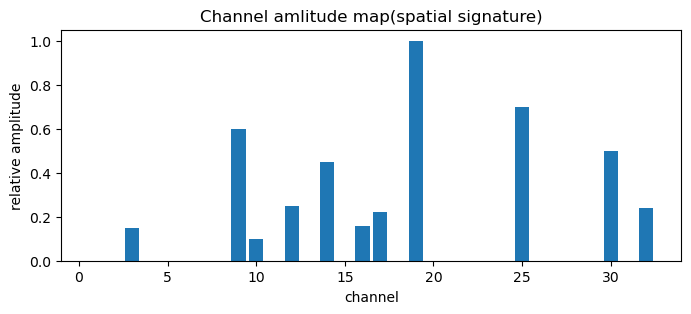

In [14]:
# plot
plt.figure(figsize=(8,3))
plt.bar(np.arange(1, n_channels+1), amp)
plt.xlabel("channel"); plt.ylabel("relative amplitude")
plt.title("Channel amlitude map(spatial signature)")
plt.show()

## Stage 3: Spike times (when spikes happen)
Evoked case: fibres fire at a fixed delay after each stimulus (TTL).
- phase 1 timing: 0.25Hz = 1 pulse every 4 s, 221 pulses
- `ttl_times = np.arange(n_pulses) * stim_period` -> 0, 4, 8, … 880 s.
- `spike_times = ttl_times + latency` — the **latency** is the travel delay from stimulus to
  electrode. It's fixed because it's the same fibre responding to the same stimulus each time.

Because I *define* these times, they are perfect **ground truth** for testing detection later.

In [18]:
# Spike time: when do these spike happen
fs = 20000 # HZ, must match the template
stim_period = 4.0  # seconds between pulses (0.25 Hz)
n_pulses = 221
latency = 0.003   # seconds - fixed delay from stimulus to spike (pick a realistic value, ~2-4ms)

# TTl (stimulus) times in seconds: 0, 4, 8 for 221 pulses
ttl_times = np.arange(n_pulses) * stim_period
spike_times = ttl_times + latency 

print("number of TTLs:", len(ttl_times))
print("first 3 TTL times (s):", ttl_times[:3])
print("last TTL time (s):", ttl_times[-1])
print("first 3 spikes times (s):", spike_times[:3]) 

number of TTLs: 221
first 3 TTL times (s): [0. 4. 8.]
last TTL time (s): 880.0
first 3 spikes times (s): [3.000e-03 4.003e+00 8.003e+00]


## Stage 4: assemble the recording
Empty (32 × N) canvas of zeros; for each spike, stamp `template × amp[ch]` onto every channel
at that spike's sample index. Result: clean multi-channel recording with the correct spatial
signature (channel 19 tallest at −1.0, scaling down correctly).

**Bug learned:** `rec[ch, start:end] += ...` uses `+=` (accumulate). Re-running the loop
without re-zeroing `rec` stacks spikes on top of themselves (trough came out −2.0 instead of
−1.0 — exactly doubled). Fix: zero the canvas *inside* the same cell, so it's safe to re-run.
General rule: any cell that uses `+=` is unsafe to re-run alone; exact 2×/3× values are the tell.


In [20]:
# Assemble the recording
n_dev_spikes = 10
dev_spikes = spike_times[:n_dev_spikes]

# recordings needs to be long enough to hold the last dev spike + a full template after it
duration_s = dev_spikes[-1] + 0.01   # last spike time + 10 ms padding 
n_samples = int(duration_s * fs)   # total samples in the recordings

rec = np.zeros((n_channels, n_samples))   # 32 X N canvas, all silent
print("recording shape:", rec.shape)

recording shape: (32, 720260)


In [26]:
# Stamping logic
""" 
for each spike: convert its time (seconds) to a sample index ( where in the array it starts)
add the template X each channel's amplitude at that position
"""
n_template = len(wave)   # how many samples the tempalte spans (40)

for t_spike in dev_spikes:
    start = int(t_spike * fs)    # seconds -> sample index
    end = start + n_template  # template occupes start;end

    # stamp onto every channel scaled by that channel's amplitude
    for ch in range(n_channels):
        rec[ch, start:end] += wave * amp[ch]

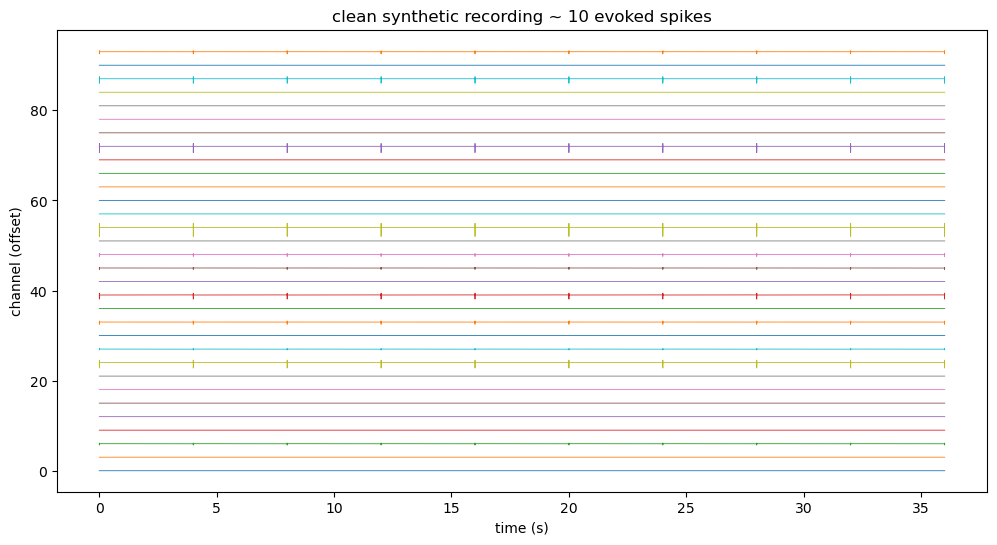

In [32]:
t_axis = np.arange(n_samples) / fs   # x-axis in seconds

plt.figure(figsize=(12, 6))
offset = 3   # vertical spacing so channels dont overlap
for ch in range(n_channels):
    plt.plot(t_axis, rec[ch] + ch * offset, lw=0.6)
plt.xlabel("time (s)"); plt.ylabel("channel (offset)")
plt.title("clean synthetic recording ~ 10 evoked spikes")
plt.show()

channel 19: trough = -2.000, peak-to-peak = 2.916
channel 25: trough = -1.400, peak-to-peak = 2.041
channel  9: trough = -1.200, peak-to-peak = 1.750
channel  3: trough = -0.300, peak-to-peak = 0.437
channel  1: trough = 0.000, peak-to-peak = 0.000


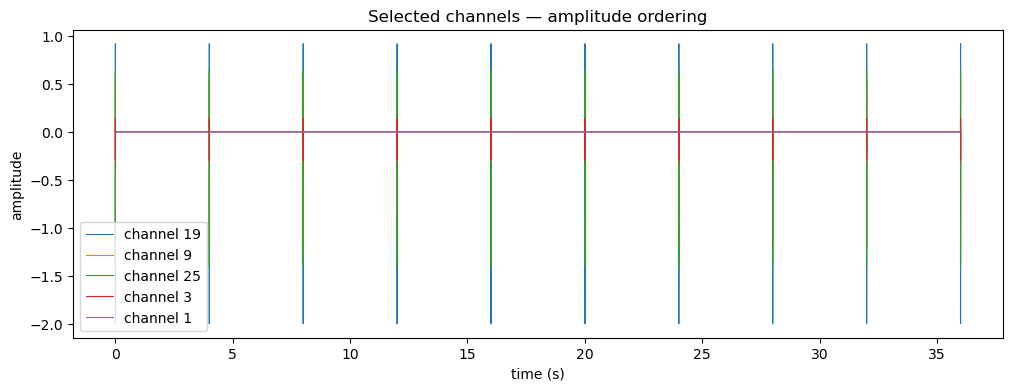

In [33]:
for ch in [18, 24, 8, 2, 0]:   # channels 19, 25, 9, 3, 1
    print(f"channel {ch+1:2d}: trough = {rec[ch].min():.3f}, peak-to-peak = {np.ptp(rec[ch]):.3f}")
plt.figure(figsize=(12, 4))
for ch in [18, 8, 24, 2, 0]:   # channel 19, 9, 25, 3, 1  (indices)
    plt.plot(t_axis, rec[ch], lw=0.8, label=f"channel {ch+1}")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Selected channels — amplitude ordering")
plt.legend()
plt.show()

In [34]:
rec = np.zeros((n_channels, n_samples))

In [35]:
n_template = len(wave)

for t_spike in dev_spikes:
    start = int(t_spike * fs)
    end = start + n_template
    for ch in range(n_channels):
        rec[ch, start:end] += wave * amp[ch]

In [36]:
for ch in [18, 24, 8, 2, 0]:
    print(f"channel {ch+1:2d}: trough = {rec[ch].min():.3f}")

channel 19: trough = -1.000
channel 25: trough = -0.700
channel  9: trough = -0.600
channel  3: trough = -0.150
channel  1: trough = 0.000


## Stage 5: Add noise

`noise = np.random.normal(0, noise_std, rec.shape)` then `noisy = rec + noise`.

- `noise_std = 0.1` vs channel-19 spike depth 1.0 → spike ~10× noise (easy on ch19).
- Same noise on channel 3 (depth 0.15) → spike barely above noise (hard).
- **Key intuition:** the same noise makes strong channels easy and weak channels hard — which
  is why pooling across channels (joint denoising) matters. Later: sweep `noise_std` to plot
  performance vs SNR.


In [39]:
# One line of noise
noise_std = 0.1
noise = np.random.normal(0, noise_std, rec.shape) # random numbers, bell-curve distribtion, mean 0(noise is equally likely + or -), standard deviation 0.1( how big the wiggles are), and rec.shape so the noise array is exactly 32XN
noisy = rec + noise

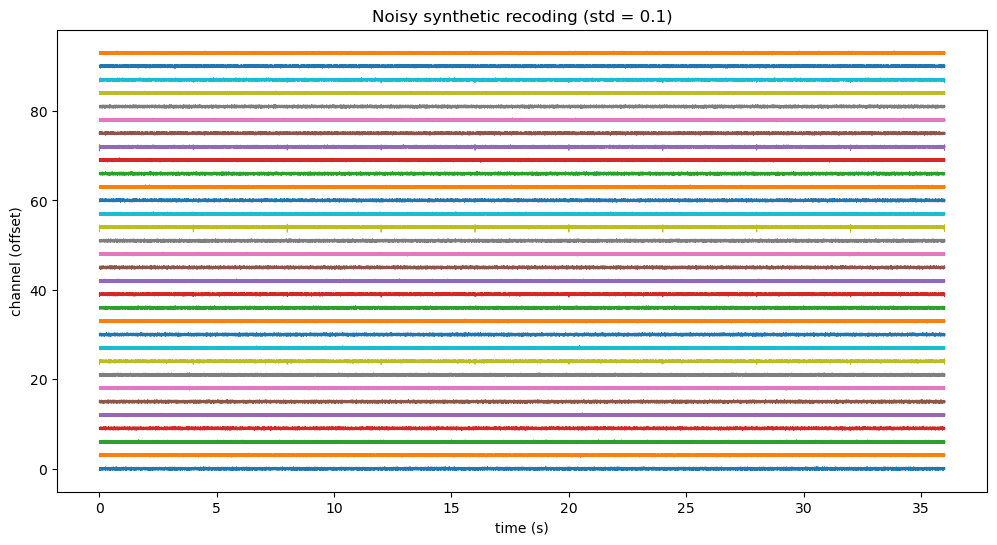

In [43]:
#plot it
t_axis = np.arange(n_samples) / fs
plt.figure(figsize=(12, 6))
offset = 3
for ch in range(n_channels):
    plt.plot(t_axis, noisy[ch] + ch * offset, lw=0.6)
plt.xlabel("time (s)"); plt.ylabel("channel (offset)")
plt.title("Noisy synthetic recoding (std = 0.1)")
plt.show()
    

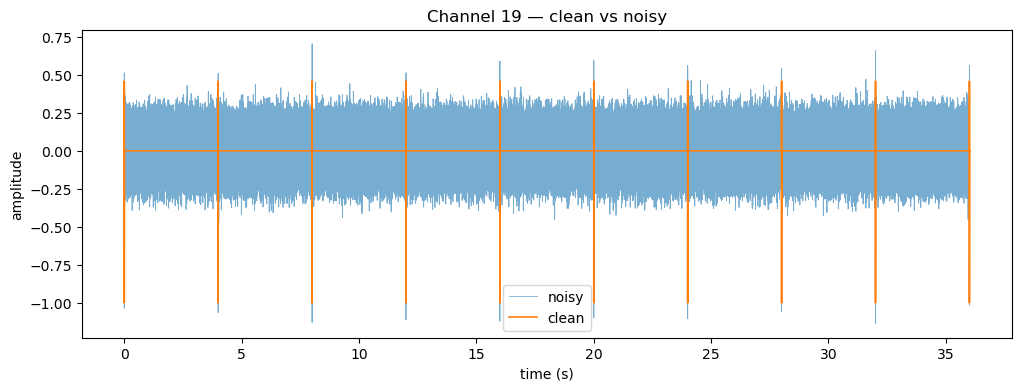

In [44]:
ch = 18  # channel 19 (the good unit)
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — clean vs noisy")
plt.legend()
plt.show()

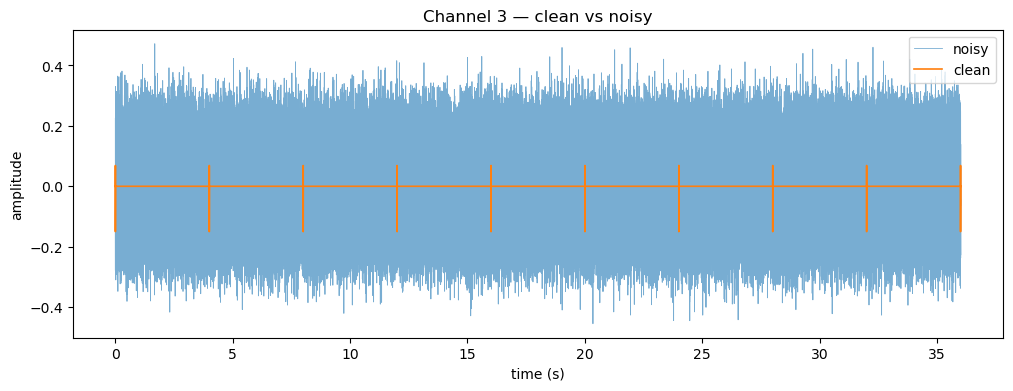

In [45]:
ch = 2 # channels 3 (weak)
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 3 — clean vs noisy")
plt.legend()
plt.show()